<a href="https://www.kaggle.com/code/hideos/minimal-ml-ops-project-daily-usd-jpy-processing?scriptVersionId=306498819" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Daily FX Series
- Datasets: https://www.kaggle.com/datasets?search=hideos+Daily+FX
- Notebooks: https://www.kaggle.com/code?searchQuery=hideos+Daily+FX

This notebook is no longer maintained because the dataset it uses has been deprecated.

---

# Summary

- **Purpose**  
  Demonstrates capabilities by visualizing USD/JPY rate changes and showing an end‑to‑end data workflow.

- **Automation**  
  Automate data updates to GitHub: use a scheduled GitHub Actions workflow to call the API, transform data, update data files, and commit updated data to the repository.  
  Automate notebook refresh: keep the Kaggle notebook graph current by scheduling the notebook to run and pull the latest raw file from GitHub

- **Documentation sync**  
  Embed the repository README into the notebook so documentation is maintained in one place and rendered live in Kaggle.

- **Benefits**  
  **Reproducibility and reliability:** automated, versioned data and CI reduce manual errors and ensure the notebook reflects the canonical dataset.  
  **Maintainability:** a single source (GitHub) for code and docs eliminates duplication and simplifies collaboration.  
  **Visibility and control:** CI logs, commit history, and scheduled runs provide operational transparency.

# Graph of USD/JPY

<Axes: xlabel='date'>

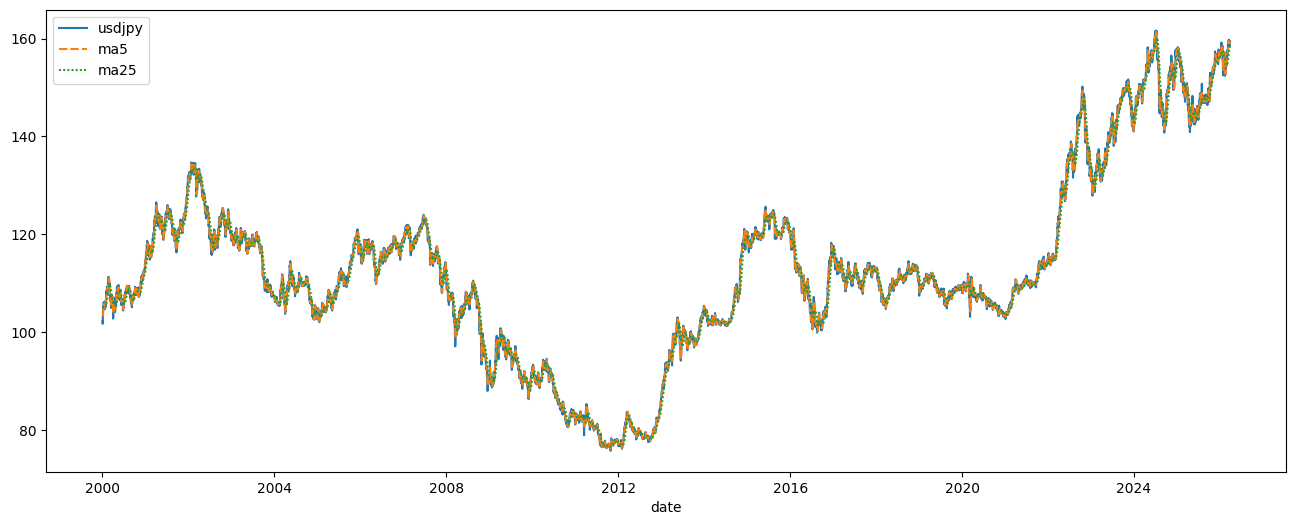

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
GITHUB_BASE="https://raw.githubusercontent.com"
GITHUB_OWNER="hide-san"
GITHUB_REPO="usdjpy-mlops"
GITHUB_BASE_URL=f"{GITHUB_BASE}/{GITHUB_OWNER}/{GITHUB_REPO}"

df_usdjpy = pd.read_csv('/kaggle/input/daily-usdjpy-dataset/usdjpy.csv', parse_dates=["date"], index_col="date")
df_usdjpy = df_usdjpy[["usdjpy", "ma5", "ma25"]]

plt.figure(figsize=(16,6))
sns.lineplot(data=df_usdjpy)

# Analysis of lag

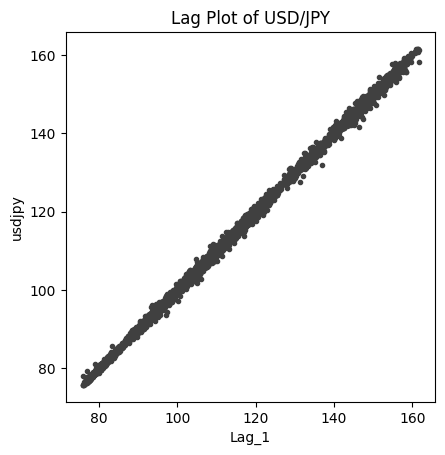

In [2]:
df_usdjpy['Lag_1'] = df_usdjpy['usdjpy'].shift(1)

X = df_usdjpy.loc[:, ['Lag_1']]
X.dropna(inplace=True)  # drop missing values in the feature set
y = df_usdjpy.loc[:, 'usdjpy']  # create the target
y, X = y.align(X, join='inner')  # drop corresponding values in target

fig, ax = plt.subplots()
ax.plot(X['Lag_1'], y, '.', color='0.25')
ax.set_aspect('equal')
ax.set_ylabel('usdjpy')
ax.set_xlabel('Lag_1')
ax.set_title('Lag Plot of USD/JPY');

# Details
The below are the details of this implementation, pulled from GitHub.

In [3]:
import requests
from IPython.display import Markdown, display

url_readme = f"{GITHUB_BASE_URL}/main/README.md"

github_readme = requests.get(url_readme)
github_readme.raise_for_status()
display(Markdown(github_readme.text))

# Minimal ML Ops Project: Automatically Collecting and Processing Daily USD/JPY Data  
[![Pylint](https://github.com/hide-san/usdjpy-mlops/actions/workflows/pylint.yml/badge.svg)](https://github.com/hide-san/usdjpy-mlops/actions/workflows/pylint.yml)

This project implements a minimal yet practical ML Ops pipeline that automatically collects, processes, and publishes daily USD/JPY exchange rate data.  
It demonstrates the core components of ML Ops — data ingestion, preprocessing, automation, reproducibility, and external visualization — using lightweight tools such as Python, GitHub Actions, and Kaggle.

The design emphasizes **responsibility separation**:
- Python handles only data logic (fetch → process → save)
- GitHub Actions handles all Kaggle interactions (download → upload → notebook trigger)

# Project Overview
The goal is to build a fully automated data pipeline that:

* Downloads the latest dataset from Kaggle (source of truth)
* Fetches new USD/JPY data from a public API
* Merges and deduplicates the dataset
* Stores the updated dataset in a structured format
* Executes automatically every day via GitHub Actions
* Publishes the dataset back to Kaggle
* Enables external visualization (e.g., Kaggle Notebook auto-run)

This project is intentionally minimal, focusing on reliability and automation rather than complex modeling.



---
# Pipeline Architecture
```
- GitHub Actions (daily scheduled run)
        ↓
- Download latest dataset from Kaggle
- fetch.py: Collect new USD/JPY data from API
- process.py: Clean and preprocess the data
- analyze.py: Compute indicators and simple signals
- Publish dataset to Kaggle
        ↓
- Kaggle Notebook auto-runs on data update
```

---
# Project Structure
```
usdjpy-mlops/
├── fetch.py          # Data ingestion
├── process.py        # Preprocessing and feature engineering
├── analyze.py        # Lightweight analysis logic
├── data/
│   └── dataset-metadata.json     # Kaggle metadata
├── .github/
│   ├── workflows/
│   │   └── pipeline.yml          # GitHub Actions automation
│   └── actions/
│       └── python-setup/         # Composite action for Python env
│           └── action.yml
├── minimal-ml-ops-project-daily-usd-jpy-processing.ipynb
├── requirements.txt
└── README.md
```

---
# Components
## **1. Data Ingestion (`fetch.py`)**
- Retrieves the latest USD/JPY exchange rate  
- Normalizes date and rate fields  
- Appends to `data/usdjpy.csv`  
- Ensures idempotency (safe re-runs)  
- Logs success/failure  

## **2. Preprocessing (`process.py`)**
- Sorts data by date  
- Calculates:
  - 5-day moving average (MA5)  
  - 25-day moving average (MA25)  
  - Daily percentage change  
- Handles duplicates and missing values  

## **3. Analysis (`analyze.py`)**
Applies simple, interpretable financial logic:
- Spike detection (e.g., ±1% daily move)  
- Trend detection (MA5 vs MA25 crossover)  
- Volatility checks  

---
# Automation with GitHub Actions
The pipeline runs automatically every day using a scheduled workflow:
```
yaml
on:
  schedule:
    - cron: "0 9 * * *"   # Runs daily at 09:00 UTC
  workflow_dispatch:       # Allows manual execution
```

---
# External Links
- **Kaggle Dataset** — https://www.kaggle.com/datasets/hideos/daily-usdjpy-dataset  
  The official dataset generated by this automated pipeline.  
  GitHub Actions updates this dataset daily by merging new API data with the latest Kaggle version, ensuring that Kaggle always serves as the single source of truth. 
  This dataset can be used directly for analysis, modeling, or visualization in Kaggle Notebooks.
- **Kaggle Notebook** — https://www.kaggle.com/code/hideos/minimal-ml-ops-project-daily-usd-jpy-processing  
  A companion notebook used for visualization and exploratory analysis of the USD/JPY dataset.  
  The notebook is configured to automatically re-run whenever the Kaggle dataset is updated, enabling always‑fresh charts, indicators, and insights without manual execution.
- **ExchangeRate Host (API)** — https://exchangerate.host  
  Public foreign exchange rates API used for fetching USD/JPY. Check usage limits and terms before commercial use. **Last checked: 2026-01-19.**
- **GitHub Repository** — https://github.com/hide-san/usdjpy-mlops/  
  Public repository containing the automated daily USD/JPY data pipeline.
> **Note:** This repository does not contain any API keys. API keys (if required) are stored securely in GitHub Actions Secrets and are never committed to the repo.

